In [21]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

In [ ]:
# ── USER CONFIG ──
HF_TOKEN     = "<INSERT_HUGGINGFACE_TOKEN>"
BASE_MODEL   = "meta-llama/Llama-3.2-1B"
CHECKPOINT_ROOT = "."  
CHECKPOINTS = sorted(d for d in os.listdir(CHECKPOINT_ROOT) if d.startswith("lora_round_"))
LOGIC_WORDS  = ["because","therefore","hence","implies","at least one"]
PROMPTS      = [
    "If x is greater than 5 and y is less than x, therefore",
    "If a triangle is isosceles, then it implies"
]
LAYER, HEAD = 0, 0    # which layer/head to inspect
MAX_LEN     = 128

In [23]:
def load_base_model():
    """Load the original Llama-3.2-1B (no LoRA) in FP16+CPU offload."""
    tokenizer = AutoTokenizer.from_pretrained(
        BASE_MODEL, use_fast=True, use_auth_token=HF_TOKEN
    )

    # **ensure we have a pad_token**
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        use_auth_token=HF_TOKEN,
        device_map="auto",
        offload_folder="offload_dir",
        offload_state_dict=True,
        torch_dtype=torch.float16,
        output_attentions=True,
        attn_implementation="eager",
    )
    model.eval()
    return model, tokenizer

In [24]:
def load_lora_model(cp_dir):
    """Load base + LoRA adapter from a checkpoint folder (8-bit+offload)."""
    # tokenizer from LoRA folder (catches any added tokens)
    tokenizer = AutoTokenizer.from_pretrained(
        cp_dir, use_fast=True, local_files_only=True
    )

    # **ensure we have a pad_token**
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        
    # base in 8-bit + offload
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        use_auth_token=HF_TOKEN,
        device_map="auto",               # shard layers across GPU/CPU
        offload_folder="offload_dir",    # where CPU-spill lives
        offload_state_dict=True,         # actually offload weights
        torch_dtype=torch.float16,       # half-precision
        output_attentions=True,
        attn_implementation="eager",
    )
    # apply adapter
    model = PeftModel.from_pretrained(base, cp_dir, local_files_only=True, device_map="auto")
    model.eval()
    return model, tokenizer


In [25]:
def avg_attention_on_keywords(model, tokenizer, text):
    """Compute mean attention to any token containing one of LOGIC_WORDS."""
    inputs = tokenizer(
        text, return_tensors="pt", truncation=True,
        padding="max_length", max_length=MAX_LEN
    ).to(model.device)
    with torch.no_grad():
        out = model(**inputs)
    attn = out.attentions[LAYER][0, HEAD].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
    idxs = [i for i,t in enumerate(tokens[:attn.shape[0]]) if any(kw in t for kw in LOGIC_WORDS)]
    return float(np.nan) if not idxs else attn[:, idxs].mean()
   

In [26]:

# 1) Evaluate base model once
base_model, base_tok = load_base_model()
base_vals = [avg_attention_on_keywords(base_model, base_tok, p) for p in PROMPTS]
print("Base model avg-attn on logic words:", [f"{v:.4f}" for v in base_vals])

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/tokenization_auto.py:898: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


Base model avg-attn on logic words: ['0.0286', '0.0253']


In [27]:
# 2) Evaluate each LoRA checkpoint
results = {cp: [] for cp in CHECKPOINTS}
for cp in CHECKPOINTS:
    path = os.path.join(CHECKPOINT_ROOT, cp)
    print("Loading", path)
    model, tokenizer = load_lora_model(path)
    for p in PROMPTS:
        avg = avg_attention_on_keywords(model, tokenizer, p)
        results[cp].append(avg)
    torch.cuda.empty_cache()

Loading ./lora_round_1_20250422_234856
Loading ./lora_round_1_20250425_212120
Loading ./lora_round_2_20250425_213706
Loading ./lora_round_3_20250425_215252
Loading ./lora_round_4_20250425_220838
Loading ./lora_round_5_20250425_222424
Loading ./lora_round_6_20250425_224009
Loading ./lora_round_7_20250425_225555


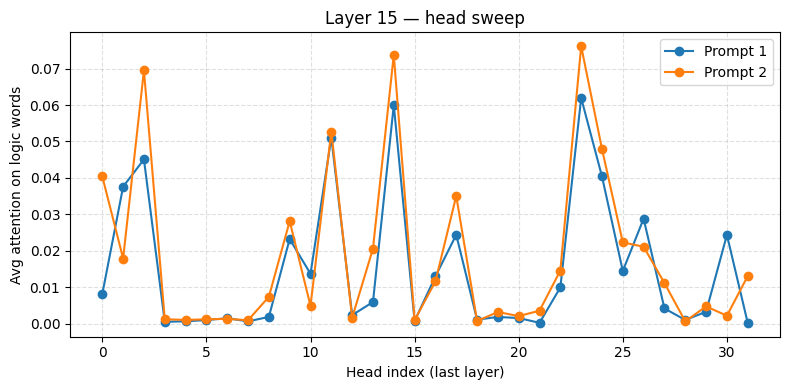

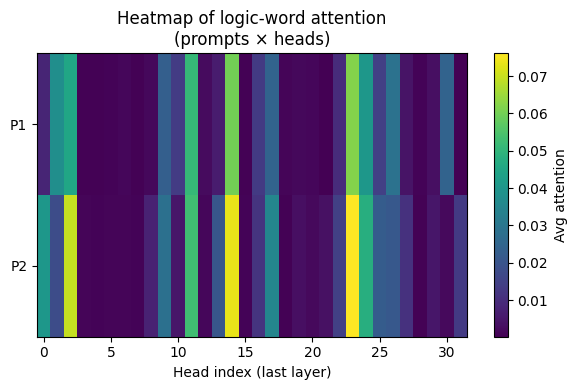

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ── 1) Redefine avg_attention to accept layer & head ──
def avg_attention_on_keywords(
    model, tokenizer, text,
    layer:int, head:int,
    max_length:int = 128,
    logic_words = [
            "because", "therefore", "hence", "implies", "at least one",
            "thus", "consequently", "if", "then", "since", "follows",
            "so", "as a result", "it follows that", "given that",
            "entails", "unless", "suppose"
        ]
):
    """
    Compute mean attention *to* any token containing a logic word substring,
    for the specified (layer, head).
    """
    # tokenize + move to device
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_length
    ).to(model.device)

    # forward
    with torch.no_grad():
        out = model(**inputs)

    # [seq_len×seq_len] attention
    attn = out.attentions[layer][0, head].cpu().numpy()
    mask = inputs.attention_mask[0].cpu().numpy().astype(bool)
    seq_len = mask.sum()

    # token list
    tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0][:seq_len])

    # find positions where any logic word is substring of token
    idxs = [i for i,t in enumerate(tokens) if any(kw in t for kw in logic_words)]
    if not idxs:
        return float("nan")

    # average attention *to* those positions (columns)
    return attn[:seq_len, :seq_len][:, idxs].mean()


# ── 2) Sweep all heads in last layer ──
# assume model,tokenizer,PROMPTS are already loaded
num_layers = model.config.num_hidden_layers
num_heads  = model.config.num_attention_heads
last_layer = num_layers - 1

# matrix heads×prompts
attn_vals = np.zeros((num_heads, len(PROMPTS)))

for h in range(num_heads):
    for i,p in enumerate(PROMPTS):
        attn_vals[h,i] = avg_attention_on_keywords(
            model, tokenizer, p,
            layer=last_layer,
            head=h
        )

# ── 3A) Line plot ──
heads = np.arange(num_heads)
plt.figure(figsize=(8,4))
for i in range(len(PROMPTS)):
    plt.plot(heads, attn_vals[:,i], marker='o', label=f"Prompt {i+1}")
plt.xlabel("Head index (last layer)")
plt.ylabel("Avg attention on logic words")
plt.title(f"Layer {last_layer} — head sweep")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── 3B) Heatmap ──
plt.figure(figsize=(6,4))
im = plt.imshow(attn_vals.T, aspect='auto')
plt.colorbar(im, label="Avg attention")
plt.xlabel("Head index (last layer)")
plt.yticks(np.arange(len(PROMPTS)), [f"P{i+1}" for i in range(len(PROMPTS))])
plt.title("Heatmap of logic-word attention\n(prompts × heads)")
plt.tight_layout()
plt.show()




/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/configuration_auto.py:1099: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


Loading ./lora_round_1_20250422_234856


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


Loading ./lora_round_1_20250425_212120
Loading ./lora_round_2_20250425_213706
Loading ./lora_round_3_20250425_215252
Loading ./lora_round_4_20250425_220838
Loading ./lora_round_5_20250425_222424
Loading ./lora_round_6_20250425_224009
Loading ./lora_round_7_20250425_225555


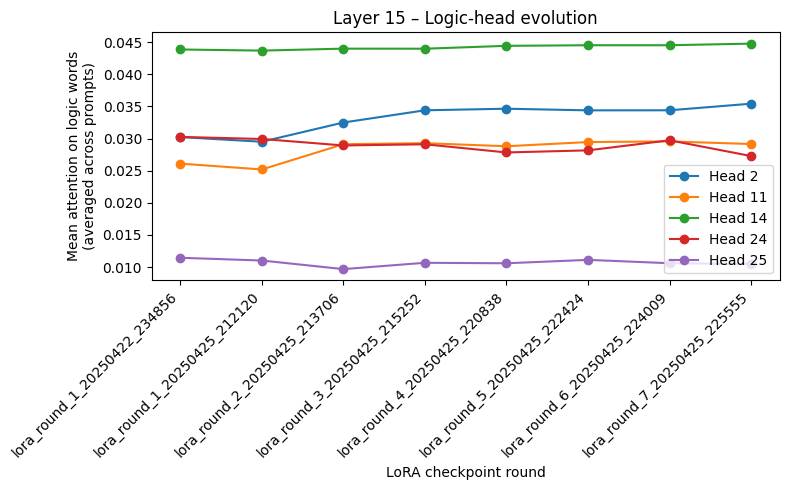

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# ── CONFIG ──
HF_TOKEN       = "<INSERT_HUGGINGFACE_TOKEN>"
BASE_MODEL     = "meta-llama/Llama-3.2-1B"
CHECKPOINT_ROOT= "."   # or "checkpoints" if your script sits above that folder
CHECKPOINTS    = sorted(d for d in os.listdir(CHECKPOINT_ROOT) if d.startswith("lora_round_"))
PROMPTS        = [
    "If x is greater than 5 and y is less than x, therefore",
    "Given that all primes greater than 2 are odd, it follows that",
    "If a triangle is isosceles, then it implies"
]
# the last layer index:
from transformers import AutoConfig
config = AutoConfig.from_pretrained(BASE_MODEL, use_auth_token=HF_TOKEN)
LAYER = config.num_hidden_layers - 1

# your “logic heads” of interest:
LOGIC_HEADS = [2, 11, 14, 24, 25]

MAX_LEN = 128

# ── HELPERS ──
def load_lora_model(cp_dir):
    """Load base FP16+offload model and apply LoRA adapter from cp_dir."""
    from transformers import AutoTokenizer, AutoModelForCausalLM
    from peft import PeftModel

    tokenizer = AutoTokenizer.from_pretrained(cp_dir, use_fast=True, local_files_only=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        use_auth_token=HF_TOKEN,
        device_map="auto",
        offload_folder="offload_dir",
        offload_state_dict=True,
        torch_dtype=torch.float16,
        output_attentions=True,
        attn_implementation="eager",
    )
    model = PeftModel.from_pretrained(base, cp_dir, local_files_only=True, device_map="auto")
    model.eval()
    return model, tokenizer

def avg_attention_on_keywords(model, tokenizer, text, layer, head):
    """Mean attention-to weight on any token containing logic keywords."""
    logic_words = ["because","therefore","hence","implies","at least one"]
    inputs = tokenizer(text, return_tensors="pt", truncation=True,
                       padding="max_length", max_length=MAX_LEN).to(model.device)
    with torch.no_grad():
        out = model(**inputs)
    attn = out.attentions[layer][0, head].cpu().numpy()
    mask = inputs.attention_mask[0].cpu().numpy().astype(bool)
    seq_len = mask.sum()
    tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0][:seq_len])
    idxs = [i for i,t in enumerate(tokens) if any(kw in t for kw in logic_words)]
    if not idxs:
        return 0.0
    return attn[:seq_len, :seq_len][:, idxs].mean()

# ── COLLECT DATA ──
# head_means[h][r] = average over prompts for head h at round index r
head_means = {h: [] for h in LOGIC_HEADS}

for cp in CHECKPOINTS:
    path = os.path.join(CHECKPOINT_ROOT, cp)
    print("Loading", path)
    model, tokenizer = load_lora_model(path)

    # for each head, compute mean over all prompts
    for h in LOGIC_HEADS:
        vals = [avg_attention_on_keywords(model, tokenizer, p, layer=LAYER, head=h)
                for p in PROMPTS]
        head_means[h].append(np.mean(vals))

    torch.cuda.empty_cache()

# ── PLOT ──
x = np.arange(1, len(CHECKPOINTS)+1)

plt.figure(figsize=(8,5))
for h in LOGIC_HEADS:
    plt.plot(x, head_means[h], marker='o', label=f"Head {h}")
plt.xticks(x, CHECKPOINTS, rotation=45, ha="right")
plt.xlabel("LoRA checkpoint round")
plt.ylabel("Mean attention on logic words\n(averaged across prompts)")
plt.title(f"Layer {LAYER} – Logic-head evolution")
plt.legend()
plt.tight_layout()
plt.show()


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/configuration_auto.py:1099: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/tokenization_auto.py:898: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. 

▶ Keyword: because


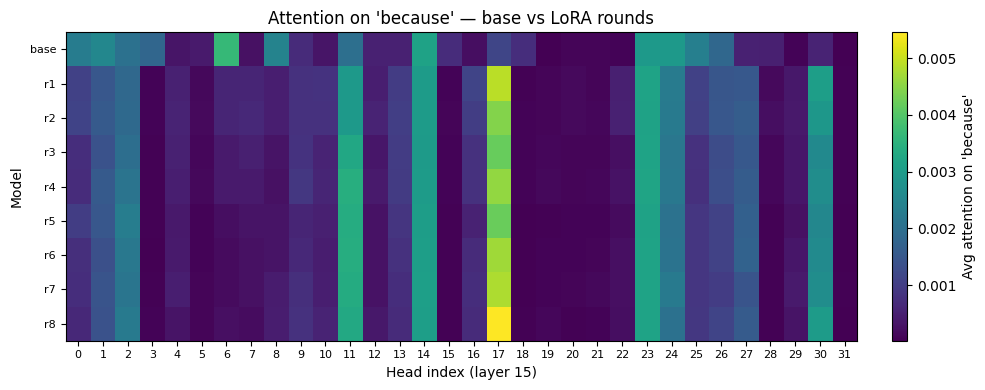

▶ Keyword: therefore


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


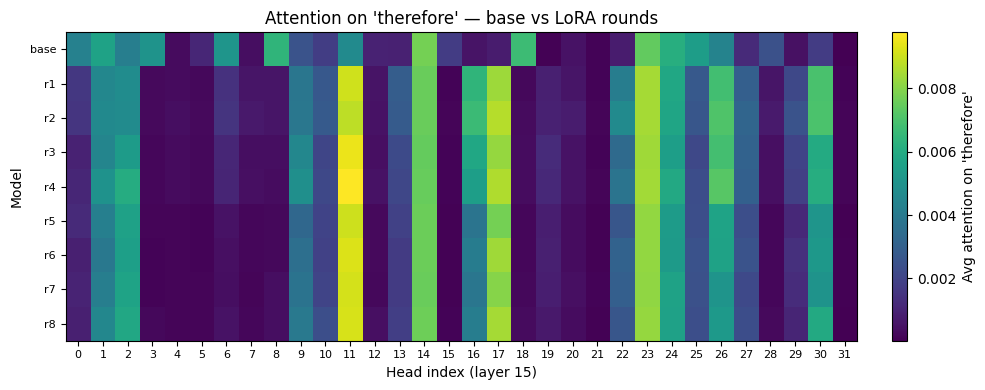

▶ Keyword: hence


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


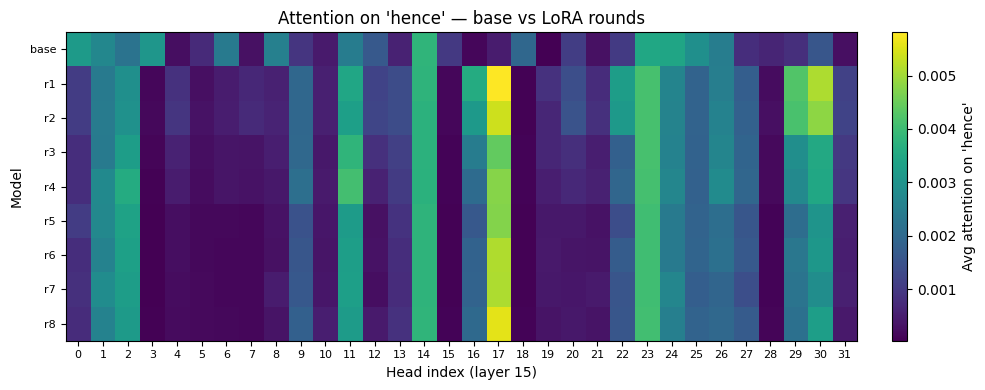

▶ Keyword: implies


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


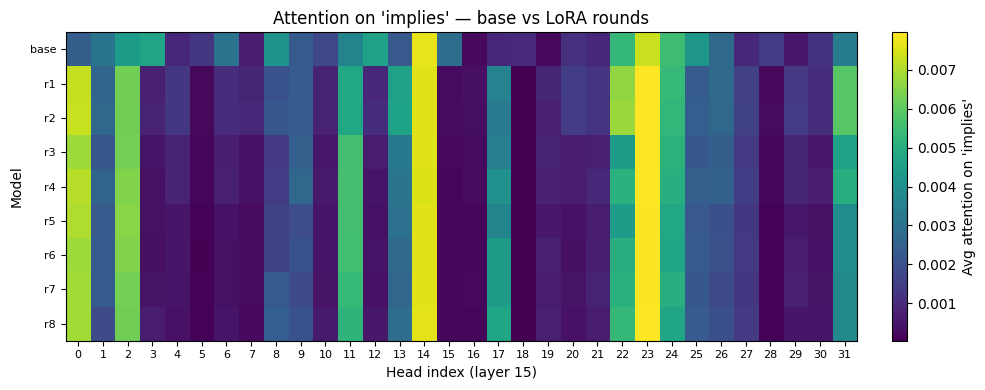

▶ Keyword: at least one


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


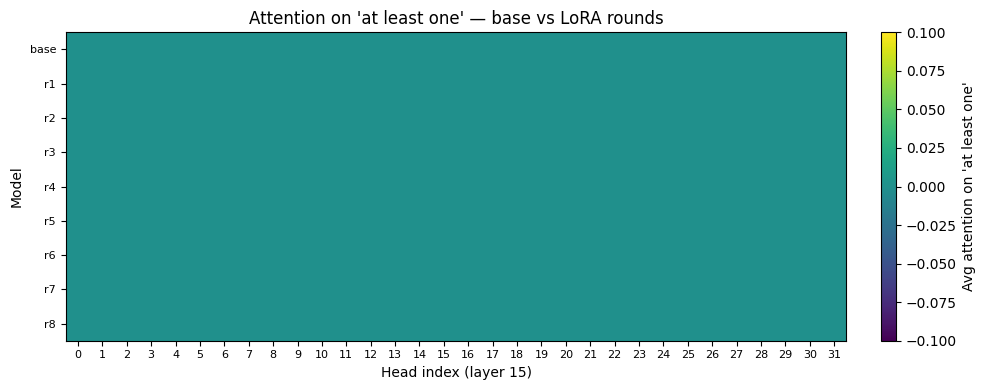

▶ Keyword: thus


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


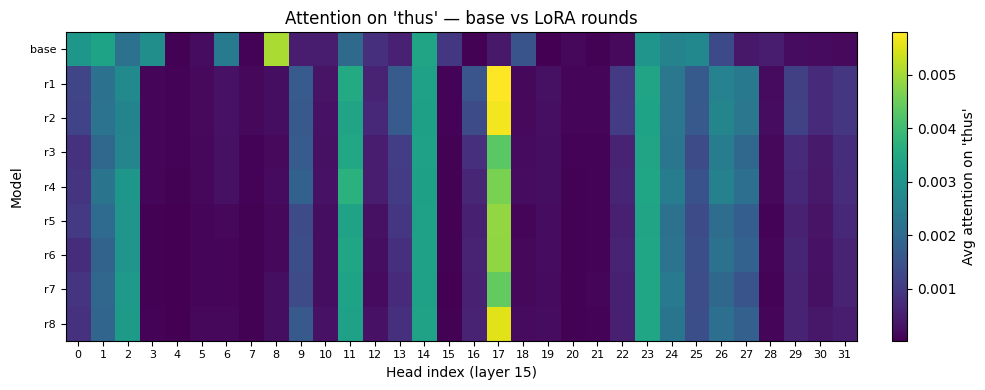

▶ Keyword: consequently


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


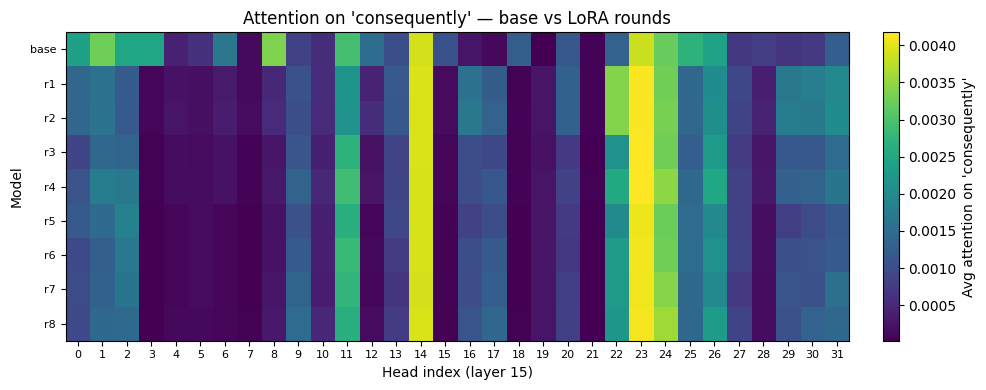

▶ Keyword: if


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


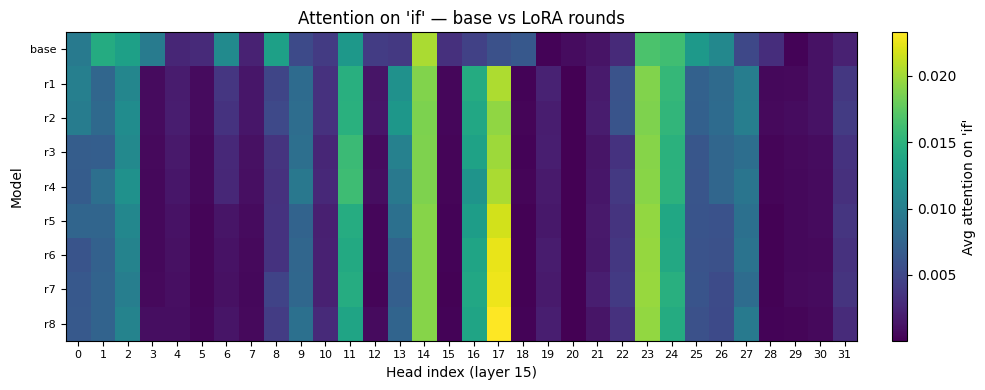

▶ Keyword: then


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


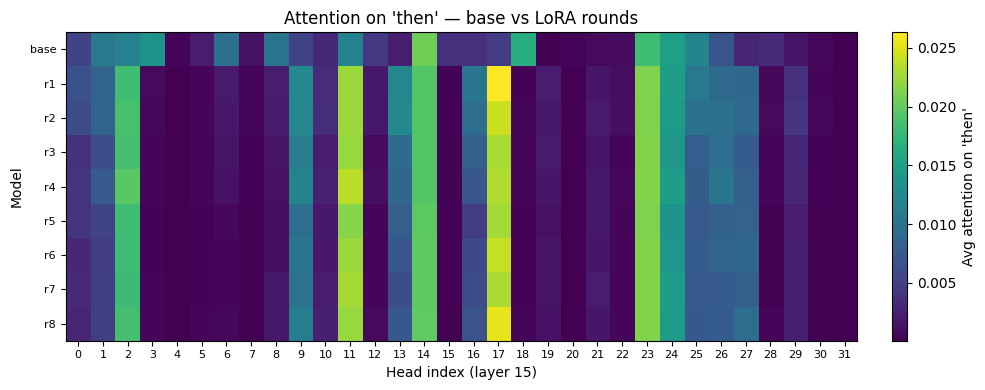

▶ Keyword: since


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


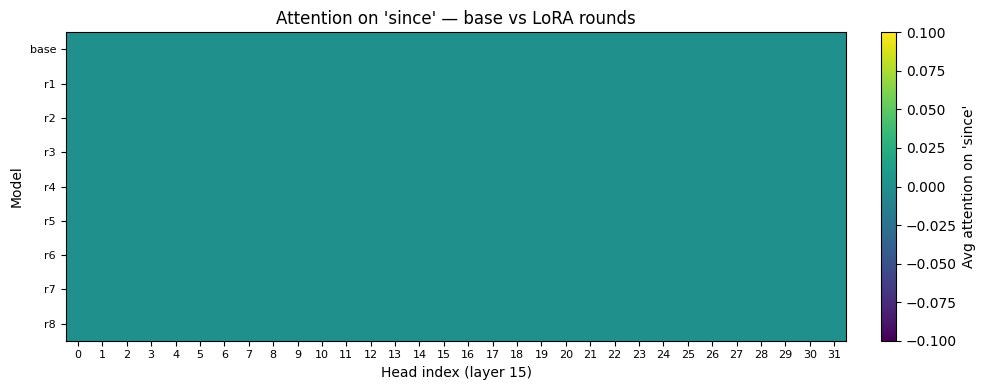

▶ Keyword: follows


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


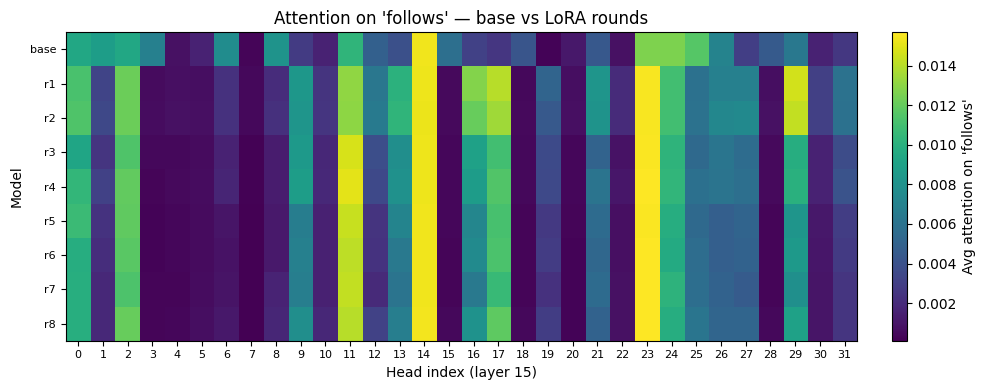

▶ Keyword: so


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


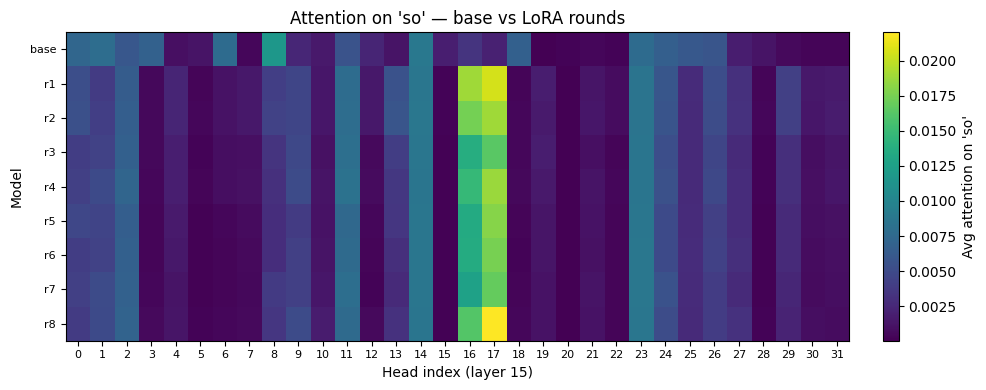

▶ Keyword: as a result


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


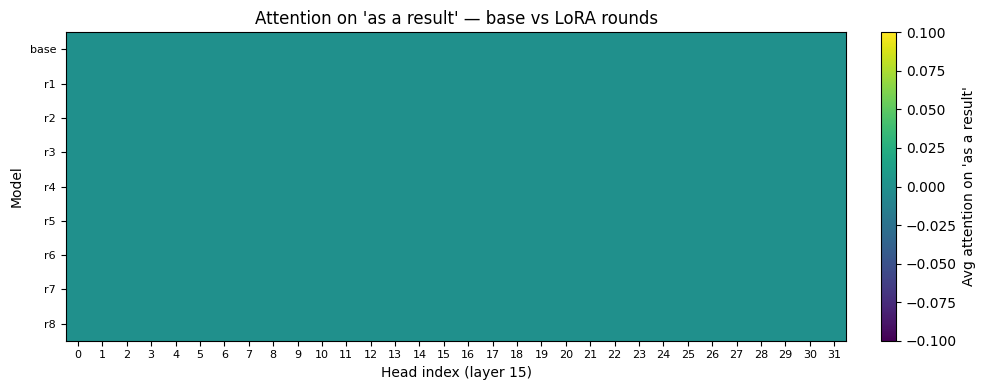

▶ Keyword: it follows that


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


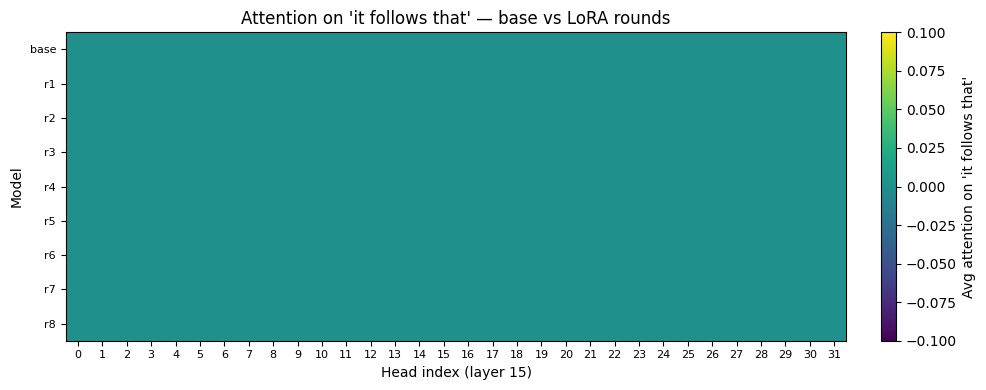

▶ Keyword: given that


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


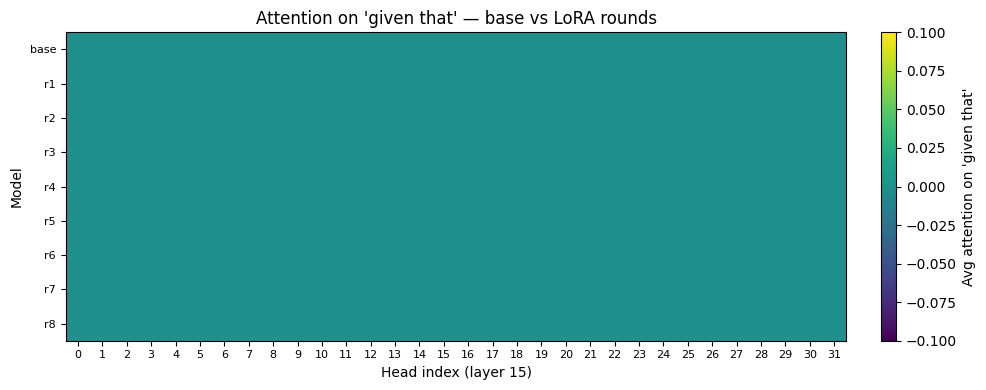

▶ Keyword: entails


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
from peft import PeftModel

# ── CONFIG ──
HF_TOKEN        = "<INSERT_HUGGINGFACE_TOKEN>"
BASE_MODEL      = "meta-llama/Llama-3.2-1B"
CHECKPOINT_ROOT = "."
CHECKPOINTS     = sorted(d for d in os.listdir(CHECKPOINT_ROOT) if d.startswith("lora_round_"))
R               = len(CHECKPOINTS)

# last layer index
config = AutoConfig.from_pretrained(BASE_MODEL, use_auth_token=HF_TOKEN)
LAYER = config.num_hidden_layers - 1

# prompts covering all logic words
PROMPTS = [
    "If A implies B and B implies C, therefore A implies C. True or False?",
    "Given that X is true, it follows that Y must be false because X and Y cannot both hold. True or False?",
    "If P then Q; if Q then R; hence if P then R. True or False?",
    "Since M entails N and N entails O, it follows that M entails O. True or False?",
    "Unless S is false, T will be true; consequently if S then T. True or False?",
    "A is greater than B, so A cannot be less than or equal to B. True or False?",
    "Because U holds and V does not hold, we can conclude U ∧ ¬V. True or False?",
    "If neither D nor E is true, then both D and E are false. True or False?",
    "As a result of G implying H, we know that if G then H. True or False?",
    "It follows that J if and only if K; therefore J implies K and K implies J. True or False?",
    "At least one of M or N is true; thus not both M and N are false. True or False?",
    "P follows from Q; so if Q then P. True or False?"
]

KEYWORDS = [
    "because","therefore","hence","implies","at least one","thus",
    "consequently","if","then","since","follows","so",
    "as a result","it follows that","given that","entails","unless"
]

MAX_LEN = 128

# ── HELPERS ──
def load_base():
    tok = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True, use_auth_token=HF_TOKEN)
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    m = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, use_auth_token=HF_TOKEN,
        device_map="auto", offload_folder="offload_dir", offload_state_dict=True,
        torch_dtype=torch.float16, output_attentions=True, attn_implementation="eager"
    )
    m.eval()
    return m, tok

def load_lora(cp_dir):
    tok = AutoTokenizer.from_pretrained(cp_dir, use_fast=True, local_files_only=True)
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, use_auth_token=HF_TOKEN,
        device_map="auto", offload_folder="offload_dir", offload_state_dict=True,
        torch_dtype=torch.float16, output_attentions=True, attn_implementation="eager"
    )
    m = PeftModel.from_pretrained(base, cp_dir, local_files_only=True, device_map="auto")
    m.eval()
    return m, tok

def avg_attn(model, tokenizer, text, layer, head, keyword):
    inp = tokenizer(text, return_tensors="pt", truncation=True,
                    padding="max_length", max_length=MAX_LEN).to(model.device)
    with torch.no_grad():
        out = model(**inp)
    attn = out.attentions[layer][0, head].cpu().numpy()
    mask = inp.attention_mask[0].cpu().numpy().astype(bool)
    seq_len = mask.sum()
    toks = tokenizer.convert_ids_to_tokens(inp.input_ids[0][:seq_len])
    idxs = [i for i,t in enumerate(toks) if keyword in t]
    return 0.0 if not idxs else attn[:seq_len, :seq_len][:, idxs].mean()

# ── load base model once ──
base_model, base_tok = load_base()
num_heads = base_model.config.num_attention_heads
torch.cuda.empty_cache()

# ── iterate over keywords ──
for KEYWORD in KEYWORDS:
    print("▶ Keyword:", KEYWORD)
    # compute base row
    base_row = np.zeros(num_heads)
    for h in range(num_heads):
        base_row[h] = np.mean([avg_attn(base_model, base_tok, p, LAYER, h, KEYWORD) for p in PROMPTS])

    # compute LoRA rows
    lora_mat = np.zeros((R, num_heads))
    for i,cp in enumerate(CHECKPOINTS):
        m, t = load_lora(os.path.join(CHECKPOINT_ROOT, cp))
        for h in range(num_heads):
            lora_mat[i,h] = np.mean([avg_attn(m, t, p, LAYER, h, KEYWORD) for p in PROMPTS])
        torch.cuda.empty_cache()

    # stack base + LoRA
    all_mat = np.vstack([base_row[None,:], lora_mat])

    # plot combined heatmap
    fig, ax = plt.subplots(figsize=(10,4))
    im = ax.imshow(all_mat, aspect='auto', cmap='viridis')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(f"Avg attention on '{KEYWORD}'")

    # x axis = heads
    ax.set_xticks(np.arange(num_heads))
    ax.set_xticklabels(np.arange(num_heads), fontsize=8)
    ax.set_xlabel(f"Head index (layer {LAYER})")

    # y axis = base + rounds
    yt = ["base"] + [f"r{j+1}" for j in range(R)]
    ax.set_yticks(np.arange(R+1))
    ax.set_yticklabels(yt, fontsize=8)
    ax.set_ylabel("Model")

    ax.set_title(f"Attention on '{KEYWORD}' — base vs LoRA rounds")
    plt.tight_layout()
    plt.show()
